In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pl.Config.set_tbl_rows(8)
plt.style.use('seaborn-v0_8-darkgrid')

DATA_DIR        = "../data"
INPUT_PARQUET   = f"{DATA_DIR}/interim/machines_filtered.parquet"
OUTPUT_PARQUET  = f"{DATA_DIR}/interim/metrics_featured.parquet"
REPORT_DIR      = "../outputs/reports"

df = pl.read_parquet(INPUT_PARQUET)

print("=" * 55)
print("  NOTEBOOK 02 — Resampling & Feature Engineering")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Machines: {df['machine'].n_unique()}")
print(f"\n  Columns present:")
for c in df.columns:
    print(f"    {c}")

  NOTEBOOK 02 — Resampling & Feature Engineering
  Rows    : 107,610
  Columns : 14
  Machines: 100

  Columns present:
    worker_name
    machine
    start_time
    end_time
    machine_cpu_iowait
    machine_cpu_kernel
    machine_cpu_usr
    machine_gpu
    machine_load_1
    machine_net_receive
    gpu_type
    cap_cpu
    cap_mem
    cap_gpu


In [2]:
# Confirm notebook 01 produced a clean parquet before we do anything
null_check = {c: df[c].null_count() for c in df.columns}
total_nulls = sum(null_check.values())

if total_nulls == 0:
    print("✅ Input parquet is clean — zero nulls across all columns")
else:
    print(f"❌ {total_nulls} nulls found in input — re-run notebook 01 first!")
    for col, nc in null_check.items():
        if nc > 0:
            print(f"   {col}: {nc:,} nulls")

✅ Input parquet is clean — zero nulls across all columns


In [3]:
# Alibaba timestamps are relative seconds from cluster start
# Multiply by 1000 → milliseconds → cast to Datetime
df = df.with_columns([
    (pl.col("start_time") * 1000).cast(pl.Datetime("ms")).alias("timestamp")
])

# CRITICAL: must sort by machine then time before ANY lag/rolling/resample
df = df.sort(["machine", "timestamp"])

print("✅ Timestamp converted and data sorted chronologically per machine")
print(f"\n  Time range:")
print(f"    Start : {df['timestamp'].min()}")
print(f"    End   : {df['timestamp'].max()}")
print(f"\n  Sample (first 3 rows):")
print(df.select(["machine", "start_time", "timestamp"]).head(3))

✅ Timestamp converted and data sorted chronologically per machine

  Time range:
    Start : 1970-01-24 07:24:56
    End   : 1970-03-16 15:53:55

  Sample (first 3 rows):
shape: (3, 3)
┌──────────────────────────┬────────────┬─────────────────────┐
│ machine                  ┆ start_time ┆ timestamp           │
│ ---                      ┆ ---        ┆ ---                 │
│ str                      ┆ i64        ┆ datetime[ms]        │
╞══════════════════════════╪════════════╪═════════════════════╡
│ 01cb92957670e37b114405a3 ┆ 2299214    ┆ 1970-01-27 14:40:14 │
│ 01cb92957670e37b114405a3 ┆ 2364322    ┆ 1970-01-28 08:45:22 │
│ 01cb92957670e37b114405a3 ┆ 2367488    ┆ 1970-01-28 09:38:08 │
└──────────────────────────┴────────────┴─────────────────────┘


In [4]:
# Raw logs are asynchronous — each machine reports at irregular intervals
# We need a uniform 5-min grid for LSTM and PatchTST sequence models
#
# group_by_dynamic groups all events within each 5-min window and averages them
# NOTE: use group_by= not by= (fixed deprecation from old notebook)

# All columns to carry through resampling (matches notebook 01 final 14-col schema)
resample_cols = [
    "machine_cpu_usr",
    "machine_cpu_kernel",
    "machine_cpu_iowait",
    "machine_gpu",
    "machine_load_1",
    "machine_net_receive",
    "cap_gpu",
    "cap_cpu",
    "cap_mem",
]

df_resampled = (
    df.group_by_dynamic("timestamp", every="5m", group_by="machine")
    .agg([
        pl.col(c).mean().cast(pl.Float32) for c in resample_cols
    ])
    .sort(["machine", "timestamp"])
)

print(f"✅ 5-minute grid complete")
print(f"   Before resampling : {df.shape[0]:,} rows")
print(f"   After resampling  : {df_resampled.shape[0]:,} rows")
print(f"   Columns           : {df_resampled.shape[1]}")

✅ 5-minute grid complete
   Before resampling : 107,610 rows
   After resampling  : 84,444 rows
   Columns           : 11


In [5]:
# Resampling creates empty 5-min windows where a machine had zero logs
# These show up as nulls — forward fill within each machine to bridge gaps

df_resampled = (
    df_resampled
    .sort(["machine", "timestamp"])
    .with_columns([
        pl.col(c).forward_fill().over("machine") for c in resample_cols
    ])
)

null_after = sum(df_resampled[c].null_count() for c in resample_cols)
print(f"✅ Resampling gaps filled")
print(f"   Nulls after ffill: {null_after}  {'(clean)' if null_after == 0 else '⚠️ check'}")
print(f"   Shape            : {df_resampled.shape[0]:,} rows × {df_resampled.shape[1]} columns")

✅ Resampling gaps filled
   Nulls after ffill: 0  (clean)
   Shape            : 84,444 rows × 11 columns


In [6]:
# IMPORTANT: machine_gpu in Alibaba trace is already a utilization value (0–100 scale)
# cap_gpu = number of GPU cards on the machine, NOT a utilization capacity
# Dividing machine_gpu / cap_gpu gives nonsense (e.g. 39.4 / 2 = 19.7 then *100 = 1970%)
# which gets clipped to 100 — that is why mean was 99.79% (wrong)
#
# Correct approach: use machine_gpu directly, just clip to 0–100 for safety

df_features = df_resampled.with_columns([
    pl.col("machine_gpu")
        .clip(0.0, 100.0)
        .alias("target_gpu_pct"),

    pl.col("machine_cpu_usr")
        .clip(0.0, 100.0)
        .alias("target_cpu_pct"),

    pl.col("machine_load_1")
        .alias("target_load"),
])

print("✅ Target columns created:")
print(f"   target_gpu_pct  — machine_gpu clipped 0–100 (already utilization scale)")
print(f"   target_cpu_pct  — machine_cpu_usr clipped 0–100")
print(f"   target_load     — machine_load_1 raw")
print()
print(df_features.select(["machine", "timestamp", "machine_gpu",
                           "target_gpu_pct", "target_cpu_pct", "target_load"]).head(5))

✅ Target columns created:
   target_gpu_pct  — machine_gpu clipped 0–100 (already utilization scale)
   target_cpu_pct  — machine_cpu_usr clipped 0–100
   target_load     — machine_load_1 raw

shape: (5, 6)
┌─────────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬─────────────┐
│ machine             ┆ timestamp    ┆ machine_gpu ┆ target_gpu_pct ┆ target_cpu_pct ┆ target_load │
│ ---                 ┆ ---          ┆ ---         ┆ ---            ┆ ---            ┆ ---         │
│ str                 ┆ datetime[ms] ┆ f32         ┆ f32            ┆ f32            ┆ f32         │
╞═════════════════════╪══════════════╪═════════════╪════════════════╪════════════════╪═════════════╡
│ 01cb92957670e37b114 ┆ 1970-01-27   ┆ 39.423077   ┆ 39.423077      ┆ 29.268719      ┆ 35.19928    │
│ 405a3               ┆ 14:40:00     ┆             ┆                ┆                ┆             │
│ 01cb92957670e37b114 ┆ 1970-01-28   ┆ 37.746193   ┆ 37.746193      ┆ 22.138973      ┆

In [7]:
# Verify targets are in expected ranges before engineering features on top
for col, expected_min, expected_max in [
    ("target_gpu_pct", 0.0, 100.0),
    ("target_cpu_pct", 0.0, 100.0),
    ("target_load",    0.0, None),
]:
    mn  = df_features[col].min()
    mx  = df_features[col].max()
    avg = df_features[col].mean()
    flag = "✅" if mn >= expected_min and (expected_max is None or mx <= expected_max) else "⚠️"
    print(f"  {flag}  {col:<18}  min={mn:6.2f}  max={mx:7.2f}  mean={avg:6.2f}")

  ✅  target_gpu_pct      min=  0.00  max= 100.00  mean= 48.57
  ✅  target_cpu_pct      min=  0.34  max=  94.96  mean= 15.79
  ✅  target_load         min=  0.80  max=1029.54  mean= 24.16


In [8]:
# Lag features give the model memory of recent history
# t-1 = 5 min ago, t-3 = 15 min ago, t-6 = 30 min ago, t-12 = 1 hour ago
#
# .over("machine") is CRITICAL — ensures lags never cross machine boundaries

lag_targets = ["target_gpu_pct", "target_cpu_pct", "target_load"]
lag_steps   = [1, 2, 3, 6, 12]

lag_exprs = []
for col in lag_targets:
    for lag in lag_steps:
        lag_exprs.append(
            pl.col(col).shift(lag).over("machine").alias(f"{col}_lag{lag}")
        )

df_features = df_features.with_columns(lag_exprs)

n_lag_cols = len(lag_exprs)
print(f"✅ Lag features added: {n_lag_cols} columns")
print(f"   Targets × steps  : {len(lag_targets)} targets × {len(lag_steps)} lags")
print(f"   Time coverage    : t-5min to t-60min")

✅ Lag features added: 15 columns
   Targets × steps  : 3 targets × 5 lags
   Time coverage    : t-5min to t-60min


In [9]:
# Rolling stats capture trend and volatility over the past 1 hour (12 × 5min)
# mean  → where is the signal trending
# std   → how volatile / spiky is the signal
# max   → worst-case peak in the last hour (important for scaling decisions)

WINDOW = 12  # 12 × 5 min = 60 minutes

roll_targets = ["target_gpu_pct", "target_cpu_pct", "target_load"]

roll_exprs = []
for col in roll_targets:
    roll_exprs.extend([
        pl.col(col).rolling_mean(WINDOW).over("machine").alias(f"{col}_rmean_1h"),
        pl.col(col).rolling_std(WINDOW).over("machine").alias(f"{col}_rstd_1h"),
        pl.col(col).rolling_max(WINDOW).over("machine").alias(f"{col}_rmax_1h"),
    ])

df_features = df_features.with_columns(roll_exprs)

n_roll_cols = len(roll_exprs)
print(f"✅ Rolling features added: {n_roll_cols} columns")
print(f"   3 stats (mean/std/max) × {len(roll_targets)} targets")
print(f"   Window: {WINDOW} steps = 60 minutes")

✅ Rolling features added: 9 columns
   3 stats (mean/std/max) × 3 targets
   Window: 12 steps = 60 minutes


In [10]:
# GPU workloads follow daily/weekly patterns
# hour_of_day and day_of_week help the model learn these cycles
# These are the most impactful features missing from the original notebook

df_features = df_features.with_columns([
    pl.col("timestamp").dt.hour().cast(pl.Float32).alias("hour_of_day"),
    pl.col("timestamp").dt.weekday().cast(pl.Float32).alias("day_of_week"),
])

print("✅ Time features added:")
print(f"   hour_of_day  : 0–23  (captures intra-day GPU demand cycles)")
print(f"   day_of_week  : 0–6   (captures weekday vs weekend patterns)")
print()
print(df_features.select(["machine", "timestamp", "hour_of_day", "day_of_week",
                           "target_gpu_pct"]).head(5))

✅ Time features added:
   hour_of_day  : 0–23  (captures intra-day GPU demand cycles)
   day_of_week  : 0–6   (captures weekday vs weekend patterns)

shape: (5, 5)
┌──────────────────────────┬─────────────────────┬─────────────┬─────────────┬────────────────┐
│ machine                  ┆ timestamp           ┆ hour_of_day ┆ day_of_week ┆ target_gpu_pct │
│ ---                      ┆ ---                 ┆ ---         ┆ ---         ┆ ---            │
│ str                      ┆ datetime[ms]        ┆ f32         ┆ f32         ┆ f32            │
╞══════════════════════════╪═════════════════════╪═════════════╪═════════════╪════════════════╡
│ 01cb92957670e37b114405a3 ┆ 1970-01-27 14:40:00 ┆ 14.0        ┆ 2.0         ┆ 39.423077      │
│ 01cb92957670e37b114405a3 ┆ 1970-01-28 08:45:00 ┆ 8.0         ┆ 3.0         ┆ 37.746193      │
│ 01cb92957670e37b114405a3 ┆ 1970-01-28 09:35:00 ┆ 9.0         ┆ 3.0         ┆ 37.644844      │
│ 01cb92957670e37b114405a3 ┆ 1970-01-28 09:40:00 ┆ 9.0         ┆ 3.0

In [11]:
# Lags and rolling windows create NaNs at the start of each machine's timeline
# (e.g. lag_12 needs 12 rows of history — first 12 rows have no lag_12 value)
# drop_nulls() removes these boundary rows cleanly

before_drop = df_features.shape[0]
final_df = df_features.drop_nulls()
dropped   = before_drop - final_df.shape[0]

print(f"✅ Boundary NaN rows dropped: {dropped:,}")
print(f"   Before : {before_drop:,} rows")
print(f"   After  : {final_df.shape[0]:,} rows")
print(f"   Columns: {final_df.shape[1]}")
print(f"\n  All columns in final ML matrix:")
for i, c in enumerate(final_df.columns):
    print(f"    {i+1:02d}. {c}")

✅ Boundary NaN rows dropped: 1,200
   Before : 84,444 rows
   After  : 83,244 rows
   Columns: 40

  All columns in final ML matrix:
    01. machine
    02. timestamp
    03. machine_cpu_usr
    04. machine_cpu_kernel
    05. machine_cpu_iowait
    06. machine_gpu
    07. machine_load_1
    08. machine_net_receive
    09. cap_gpu
    10. cap_cpu
    11. cap_mem
    12. target_gpu_pct
    13. target_cpu_pct
    14. target_load
    15. target_gpu_pct_lag1
    16. target_gpu_pct_lag2
    17. target_gpu_pct_lag3
    18. target_gpu_pct_lag6
    19. target_gpu_pct_lag12
    20. target_cpu_pct_lag1
    21. target_cpu_pct_lag2
    22. target_cpu_pct_lag3
    23. target_cpu_pct_lag6
    24. target_cpu_pct_lag12
    25. target_load_lag1
    26. target_load_lag2
    27. target_load_lag3
    28. target_load_lag6
    29. target_load_lag12
    30. target_gpu_pct_rmean_1h
    31. target_gpu_pct_rstd_1h
    32. target_gpu_pct_rmax_1h
    33. target_cpu_pct_rmean_1h
    34. target_cpu_pct_rstd_1h
    3

In [12]:
final_df.write_parquet(OUTPUT_PARQUET, compression="snappy")

saved_mb = os.path.getsize(OUTPUT_PARQUET) / 1024**2
print(f"💾 Saved: {OUTPUT_PARQUET}")
print(f"   Size    : {saved_mb:.2f} MB")
print(f"   Rows    : {final_df.shape[0]:,}")
print(f"   Columns : {final_df.shape[1]}")

💾 Saved: ../data/interim/metrics_featured.parquet
   Size    : 10.33 MB
   Rows    : 83,244
   Columns : 40


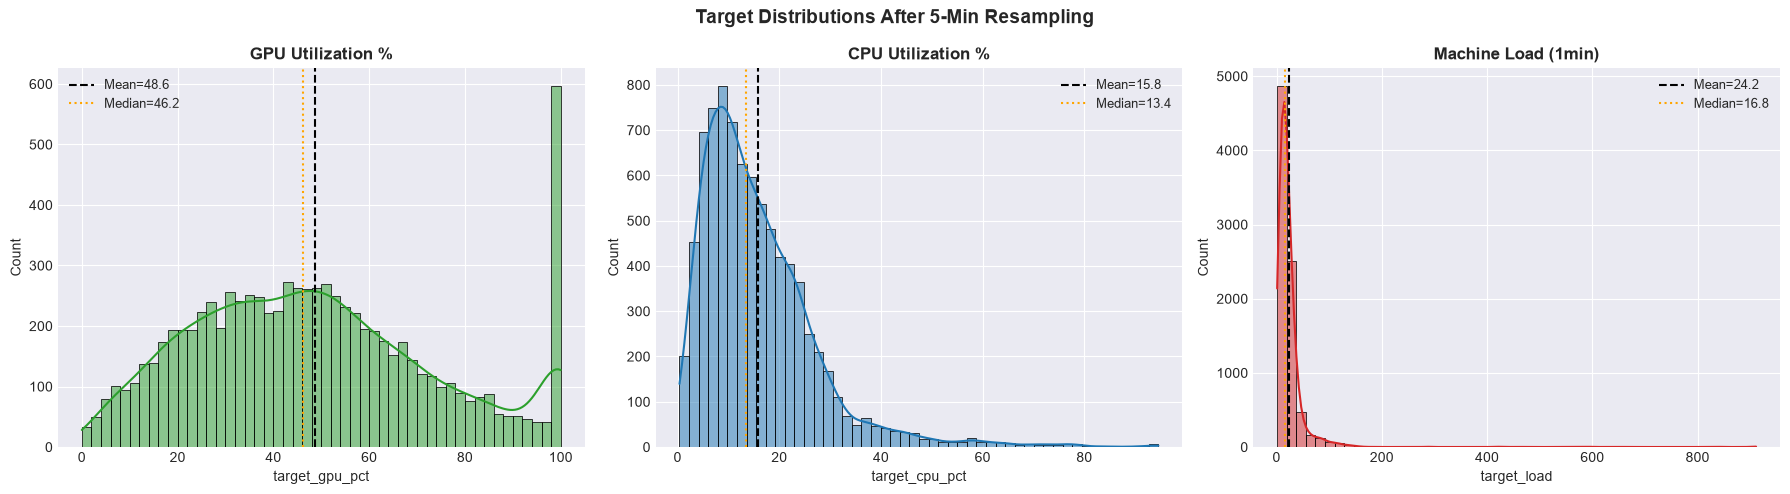

✅ Saved: 06_resampled_target_distributions.png


In [13]:
import matplotlib.pyplot as plt

sample = final_df.sample(fraction=0.1, seed=42).to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Target Distributions After 5-Min Resampling", fontsize=14, fontweight="bold")

targets = [
    ("target_gpu_pct", "GPU Utilization %",  "#2ca02c"),
    ("target_cpu_pct", "CPU Utilization %",  "#1f77b4"),
    ("target_load",    "Machine Load (1min)","#d62728"),
]

for ax, (col, title, color) in zip(axes, targets):
    data = sample[col].dropna()
    sns.histplot(data, bins=50, ax=ax, color=color, kde=True)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5, label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":",  linewidth=1.5, label=f"Median={data.median():.1f}")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/06_resampled_target_distributions.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 06_resampled_target_distributions.png")

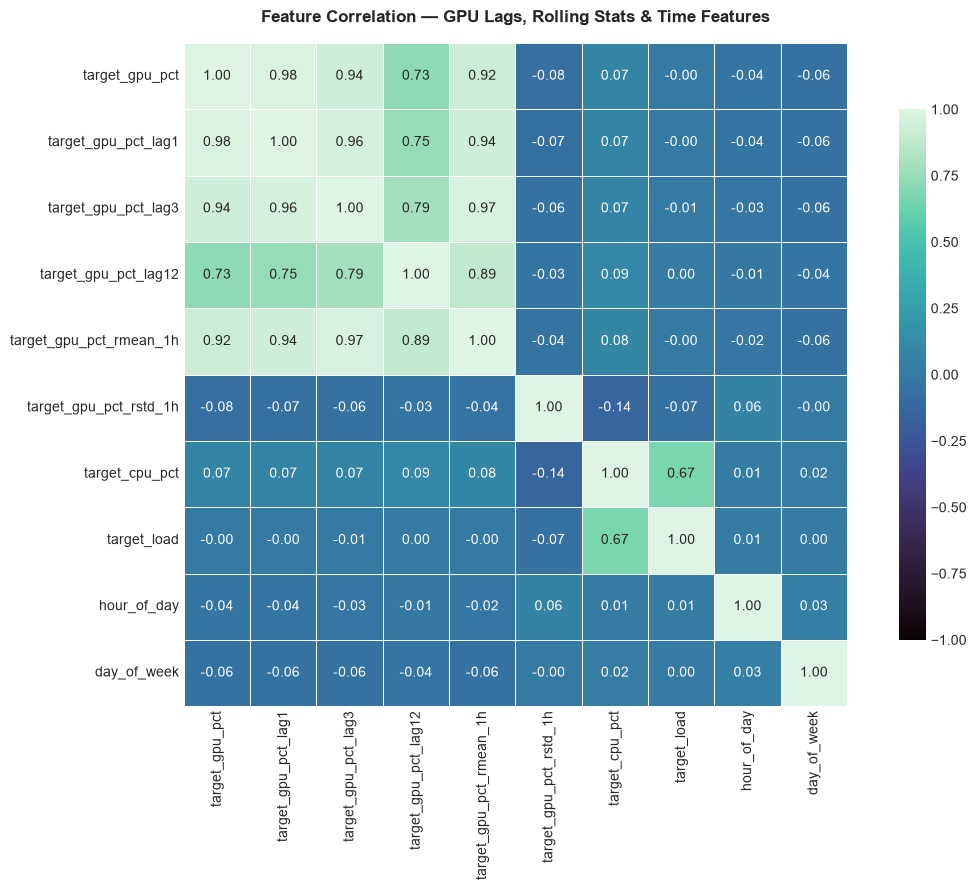

✅ Saved: 07_feature_correlation.png


In [14]:
# Check correlations across all engineered features
# Confirms lag and rolling features carry useful signal
feat_cols = [
    "target_gpu_pct", "target_gpu_pct_lag1", "target_gpu_pct_lag3",
    "target_gpu_pct_lag12", "target_gpu_pct_rmean_1h", "target_gpu_pct_rstd_1h",
    "target_cpu_pct", "target_load", "hour_of_day", "day_of_week"
]

corr = sample[feat_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako",
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8}, square=True)
plt.title("Feature Correlation — GPU Lags, Rolling Stats & Time Features", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/07_feature_correlation.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 07_feature_correlation.png")

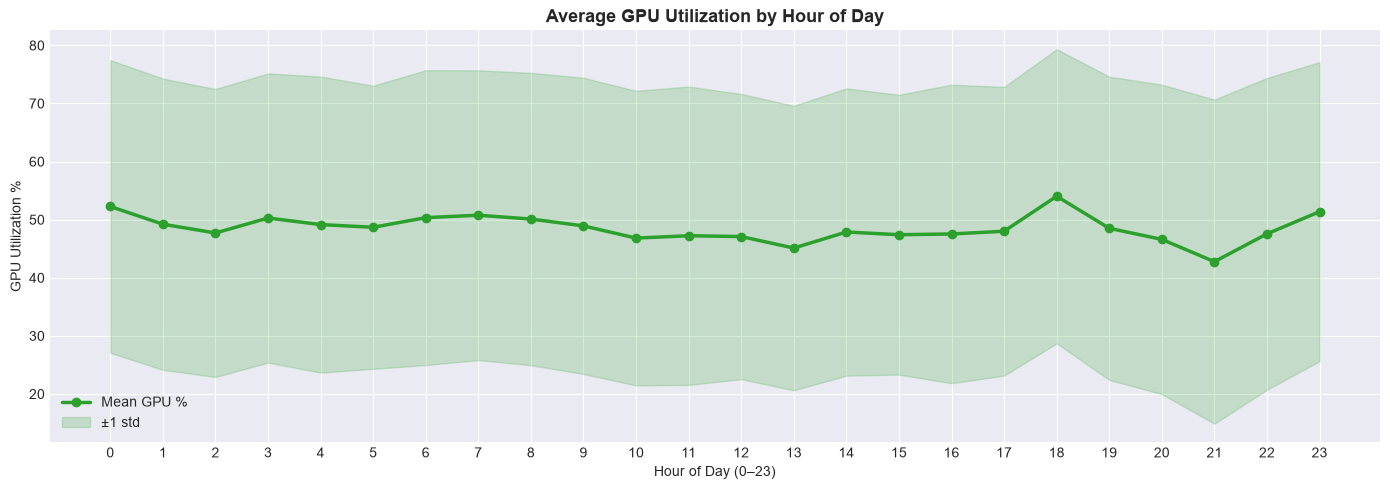

✅ Saved: 08_gpu_by_hour.png


In [15]:
# This plot shows WHY hour_of_day matters as a feature
# If GPU demand peaks at certain hours, the model needs to know the time

hourly = (
    final_df
    .group_by("hour_of_day")
    .agg([
        pl.col("target_gpu_pct").mean().alias("mean_gpu"),
        pl.col("target_gpu_pct").std().alias("std_gpu"),
    ])
    .sort("hour_of_day")
    .to_pandas()
)

plt.figure(figsize=(14, 5))
plt.plot(hourly["hour_of_day"], hourly["mean_gpu"], color="#2ca02c", linewidth=2.5, marker="o", label="Mean GPU %")
plt.fill_between(
    hourly["hour_of_day"],
    hourly["mean_gpu"] - hourly["std_gpu"],
    hourly["mean_gpu"] + hourly["std_gpu"],
    alpha=0.2, color="#2ca02c", label="±1 std"
)
plt.title("Average GPU Utilization by Hour of Day", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("GPU Utilization %")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/08_gpu_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 08_gpu_by_hour.png")

In [16]:
print("=" * 55)
print("  NOTEBOOK 02 COMPLETE")
print("=" * 55)
print(f"  Input rows          : {df.shape[0]:,}")
print(f"  After 5-min resample: {df_resampled.shape[0]:,}")
print(f"  After boundary drop : {final_df.shape[0]:,}")
print(f"  Final columns       : {final_df.shape[1]}")
print(f"  Lag features        : {len(lag_exprs)}  (t-1,2,3,6,12 × 3 targets)")
print(f"  Rolling features    : {len(roll_exprs)}  (mean/std/max × 3 targets)")
print(f"  Time features       : hour_of_day, day_of_week")
print(f"  Saved               : {saved_mb:.2f} MB → {OUTPUT_PARQUET}")
print(f"  EDA charts          : 3 PNGs → {REPORT_DIR}")
print("=" * 55)
print("\n✅ Ready for → 03_lgbm_baseline.ipynb")

  NOTEBOOK 02 COMPLETE
  Input rows          : 107,610
  After 5-min resample: 84,444
  After boundary drop : 83,244
  Final columns       : 40
  Lag features        : 15  (t-1,2,3,6,12 × 3 targets)
  Rolling features    : 9  (mean/std/max × 3 targets)
  Time features       : hour_of_day, day_of_week
  Saved               : 10.33 MB → ../data/interim/metrics_featured.parquet
  EDA charts          : 3 PNGs → ../outputs/reports

✅ Ready for → 03_lgbm_baseline.ipynb
